General results
------------------

Helpful
User-initiated mean: 4.25
System-initiated mean: 4.17
p-value: 0.754

Pleasant
User-initiated mean: 4.33
System-initiated mean: 3.83
p-value: 0.007

Use again
User-initiated mean: 4.42
System-initiated mean: 3.83
p-value: 0.046

Unwanted moments
User-initiated mean: 1.83
System-initiated mean: 1.92
p-value: 0.723

Mental demand
User-initiated mean: 2.67
System-initiated mean: 2.67
p-value: 1.0

Effort
User-initiated mean: 3.25
System-initiated mean: 3.08
p-value: 0.689

Frustration
User-initiated mean: 2.92
System-initiated mean: 2.5
p-value: 0.137

Gender results
------------------

Helpful
Male user mean: 3.8
Male system mean: 4.4
Female user mean: 4.57
Female system mean: 4.0
Gender p-value: 0.012

Pleasant
Male user mean: 4.0
Male system mean: 3.8
Female user mean: 4.57
Female system mean: 3.86
Gender p-value: 0.09

Use again
Male user mean: 4.4
Male system mean: 4.2
Female user mean: 4.43
Female system mean: 3.57
Gender p-value: 0.225

U

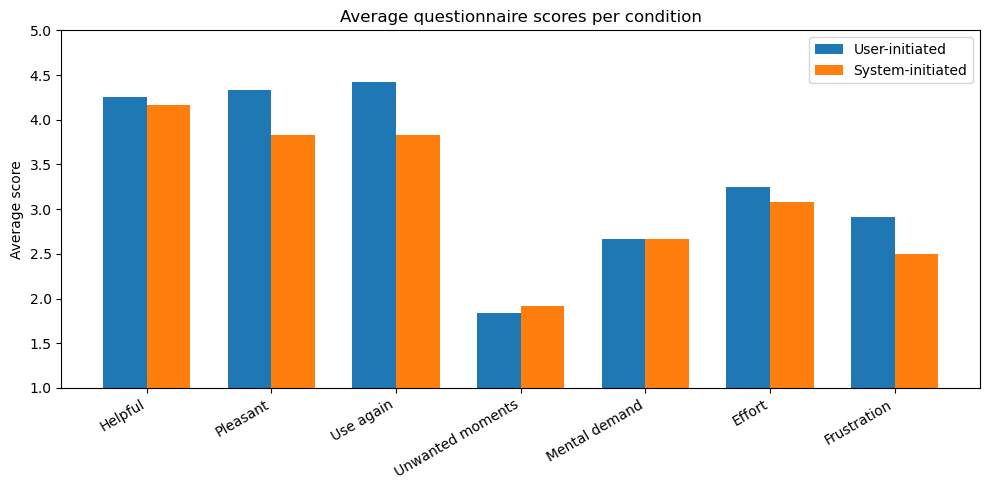

In [17]:
import pandas as pd
from scipy.stats import ttest_rel, ttest_ind
import matplotlib.pyplot as plt
import numpy as np

# Load data

data = pd.read_csv("analysis.csv", sep=";")

# Questionnaire measures

measures = {
    "Helpful": ("user_helpful", "system_helpful"),
    "Pleasant": ("user_pleasant", "system_pleasant"),
    "Use again": ("user_use_again", "system_use_again"),
    "Unwanted moments": ("user_unwanted_moments", "system_unwanted_moments"),
    "Mental demand": ("user_mental_demand", "system_mental_demand"),
    "Effort": ("user_effort", "system_effort"),
    "Frustration": ("user_frustration", "system_frustration")
}

# General paired-samples t-tests

print("General results")
print("------------------")

for name, (user_col, system_col) in measures.items():

    test = ttest_rel(data[user_col], data[system_col])

    print("\n" + name)
    print("User-initiated mean:", round(data[user_col].mean(), 2))
    print("System-initiated mean:", round(data[system_col].mean(), 2))
    print("p-value:", round(test.pvalue, 3))


# Gender analysis

print("\nGender results")
print("------------------")

for name, (user_col, system_col) in measures.items():

    male_data = data[data["gender"] == "male"]
    female_data = data[data["gender"] == "female"]

    male_difference = male_data[system_col] - male_data[user_col]
    female_difference = female_data[system_col] - female_data[user_col]

    test = ttest_ind(male_difference, female_difference, equal_var=False)

    print("\n" + name)
    print("Male user mean:", round(male_data[user_col].mean(), 2))
    print("Male system mean:", round(male_data[system_col].mean(), 2))
    print("Female user mean:", round(female_data[user_col].mean(), 2))
    print("Female system mean:", round(female_data[system_col].mean(), 2))
    print("Gender p-value:", round(test.pvalue, 3))


# Plot average questionnaire scores

names = []
user_means = []
system_means = []

for name, (user_col, system_col) in measures.items():

    names.append(name)
    user_means.append(data[user_col].mean())
    system_means.append(data[system_col].mean())

x = np.arange(len(names))
width = 0.35

plt.figure(figsize=(10, 5))

plt.bar(x - width/2, user_means, width, label="User-initiated")
plt.bar(x + width/2, system_means, width, label="System-initiated")

plt.ylabel("Average score")
plt.title("Average questionnaire scores per condition")
plt.xticks(x, names, rotation=30, ha="right")
plt.ylim(1, 5)
plt.legend()

plt.tight_layout()
plt.show()